In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# 🌿 From Global Trends to Consumer Reality

## Uncovering Hidden Patterns in Skincare Behavior through Data-Driven Segmentation

### Machine Learning | Consumer Analytics | Google Trends | Behavioural Segmentation

---

## Project Overview

The skincare industry is rapidly evolving, with increasing consumer interest in both traditional organic skincare products and advanced aesthetic treatments. However, rising global trends do not necessarily translate into changes in consumer behavior or product satisfaction.

This project integrates multiple data sources—including Amazon Beauty Reviews, Google Trends, and geographical preference data—to investigate how global skincare trends relate to real consumer behavior.

Using exploratory data analysis (EDA), feature engineering, correlation analysis, and K-Means clustering, the project uncovers hidden behavioural segments and provides insights into consumer preferences across different countries and regions.

Rather than relying solely on trend popularity, this analysis demonstrates how combining multiple data sources can reveal deeper consumer behaviour patterns and support more informed business decision-making.

---

## Project Objectives

- Analyze global skincare trends over time using Google Trends.
- Compare organic and aesthetic skincare preferences across different countries.
- Investigate whether global trend popularity influences consumer product ratings.
- Perform feature engineering to create meaningful analytical variables.
- Explore relationships between consumer behaviour and trend dynamics.
- Apply Machine Learning (K-Means Clustering) to identify hidden behavioural segments.
- Generate actionable business insights through data visualization and exploratory analytics.

---

## Datasets Used

This project combines three complementary datasets to provide a multi-level understanding of skincare behaviour.

### 1. Amazon Beauty Reviews
- Over **1.3 million** consumer reviews
- Product ratings
- Product identifiers
- Review timestamps

### 2. Google Trends
- Global search interest for:
  - Aesthetic skincare
  - Organic skincare

### 3. Geographical Preference Dataset
- Country-level skincare preferences
- Organic vs aesthetic interest
- Regional comparison

---

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Google Trends
- Jupyter / Kaggle Notebook

---

## Machine Learning Technique

### Unsupervised Machine Learning

**Algorithm Used**

- K-Means Clustering

The clustering model groups products according to:

- Average Product Rating
- Trend Gap (Aesthetic − Organic)

This allows hidden behavioural segments to be identified without requiring labelled data.

---

## Analytical Workflow

The project follows an end-to-end data analytics and machine learning pipeline.

1. Import required libraries
2. Load multiple datasets
3. Clean and preprocess the data
4. Integrate trend and consumer review datasets
5. Perform feature engineering
6. Conduct exploratory data analysis (EDA)
7. Analyze global skincare trends
8. Explore geographical consumer preferences
9. Perform correlation analysis
10. Apply K-Means clustering
11. Interpret behavioural segments
12. Generate business insights and conclusions

---

## Business Value

This project demonstrates how integrating consumer reviews with external trend data can help businesses:

- Understand changing consumer preferences
- Identify regional market differences
- Discover hidden customer segments
- Support product positioning strategies
- Improve marketing and business decision-making using data

---

## Author

**Anum Ahmed**

MSc Data Analytics

Machine Learning • Consumer Analytics • Business Analytics

---

> **Portfolio Note:** This project demonstrates an end-to-end machine learning workflow by integrating large-scale consumer review data, Google Trends, geographical analysis, feature engineering, exploratory data analysis, and unsupervised learning to uncover hidden patterns in skincare behaviour.

# 1. Import Required Libraries

This section imports the Python libraries required for data manipulation, data visualization, statistical analysis, and machine learning. These libraries support the complete analytical workflow, from data preprocessing to behavioural segmentation.

In [1]:
# ============================================================
# Import Required Libraries
# ============================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Evaluation
from sklearn.metrics import silhouette_score

# Statistical Analysis
from scipy.stats import pearsonr

# Notebook Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Plot Styling
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Load the Datasets

This project integrates three complementary datasets to analyse skincare behaviour from multiple perspectives.

The datasets include:

- **Amazon Beauty Reviews Dataset:** Product reviews, ratings, and review timestamps.
- **Google Trends Dataset:** Global search interest in organic and aesthetic skincare over time.
- **Country-Level Preference Dataset:** Regional interest in organic and aesthetic skincare across different countries.

These datasets form the foundation for analysing consumer behaviour, temporal trends, and geographical preferences.

In [5]:
# ============================================================
# 2. Load the Datasets
# ============================================================

# Amazon Beauty Reviews Dataset
amazon_reviews = pd.read_csv(
    "/kaggle/input/datasets/anumahmed1015/cosmetic-dataset/Amazon_Beauty_Recommendation.csv"
)

# Google Trends (Time-Series)
google_trends = pd.read_csv(
    "/kaggle/input/datasets/anumahmed1015/cosmetic-dataset/organic vs aesthetic.csv"
)

# Country-Level Preference Dataset
country_preferences = pd.read_csv(
    "/kaggle/input/datasets/anumahmed1015/country-level-cosmetic/geoMap.csv",
    header=1
)

print("=" * 70)
print("Datasets Loaded Successfully")
print("=" * 70)

print(f"Amazon Reviews Dataset        : {amazon_reviews.shape}")
print(f"Google Trends Dataset         : {google_trends.shape}")
print(f"Country Preference Dataset    : {country_preferences.shape}")

Datasets Loaded Successfully
Amazon Reviews Dataset        : (1348246, 6)
Google Trends Dataset         : (268, 3)
Country Preference Dataset    : (250, 3)


# 4. Data Preparation

Before integrating multiple datasets, each dataset is examined and prepared to ensure consistency, accuracy, and compatibility.

The data preparation process includes:

- Inspecting dataset structure and quality.
- Identifying missing values and data types.
- Converting variables into appropriate formats.
- Preparing temporal information for trend analysis.
- Standardising the datasets for subsequent analysis and machine learning.

In [16]:
# ============================================================
# 4. Data Preparation
# ============================================================

# Create working copies to preserve the original datasets
amazon_df = amazon_reviews.copy()
trends_df = google_trends.copy()
country_df = country_preferences.copy()

print("Working copies created successfully.")

Working copies created successfully.


In [17]:
# ============================================================
# Dataset Overview
# ============================================================

def dataset_summary(df, name):

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(f"Shape: {df.shape}")

    print("\nColumn Names:")
    print(df.columns.tolist())

    print("\nData Types:")
    display(df.dtypes.to_frame(name="Data Type"))

    print("\nMissing Values:")
    display(df.isnull().sum().to_frame(name="Missing Values"))

    print("\nFirst Five Records:")
    display(df.head())


dataset_summary(amazon_df, "Amazon Beauty Reviews Dataset")
dataset_summary(trends_df, "Google Trends Dataset")
dataset_summary(country_df, "Country Preference Dataset")

Amazon Beauty Reviews Dataset
Shape: (1348246, 6)

Column Names:
['UserId', 'ProductId', 'ProductType', 'Rating', 'Timestamp', 'URL']

Data Types:


,Data Type
UserId,object
ProductId,object
ProductType,object
Rating,int64
Timestamp,int64
URL,object



Missing Values:


,Missing Values
UserId,0
ProductId,0
ProductType,0
Rating,0
Timestamp,0
URL,0



First Five Records:


...

,Data Type
Country,object
organic skincare: (4/11/25 - 4/11/26),object
aesthetic skincare: (4/11/25 - 4/11/26),object



Missing Values:


,Missing Values
Country,0
organic skincare: (4/11/25 - 4/11/26),190
aesthetic skincare: (4/11/25 - 4/11/26),195



First Five Records:


,Country,organic skincare: (4/11/25 - 4/11/26),aesthetic skincare: (4/11/25 - 4/11/26)
0,St. Helena,91%,9%
1,Australia,80%,20%
2,New Zealand,86%,14%
3,United Arab Emirates,77%,23%
4,Ireland,83%,17%


In [18]:
# ============================================================
# Amazon Dataset
# ============================================================

# Convert Unix timestamp to datetime
amazon_df["Review_Date"] = pd.to_datetime(
    amazon_df["Timestamp"],
    unit="s"
)

# Extract review year
amazon_df["Year"] = amazon_df["Review_Date"].dt.year

# Keep only years available in Google Trends
amazon_df = amazon_df[
    amazon_df["Year"] >= 2004
].copy()


# ============================================================
# Google Trends Dataset
# ============================================================

# Rename columns
trends_df.columns = [
    "Date",
    "Aesthetic_Trend",
    "Organic_Trend"
]

# Convert date column
trends_df["Date"] = pd.to_datetime(trends_df["Date"])

# Extract year
trends_df["Year"] = trends_df["Date"].dt.year


# ============================================================
# Country Preference Dataset
# ============================================================

# Rename columns
country_df.columns = [
    "Country",
    "Organic",
    "Aesthetic"
]

# Remove percentage symbols
country_df["Organic"] = (
    country_df["Organic"]
    .astype(str)
    .str.replace("%", "", regex=False)
)

country_df["Aesthetic"] = (
    country_df["Aesthetic"]
    .astype(str)
    .str.replace("%", "", regex=False)
)

# Convert to numeric
country_df["Organic"] = pd.to_numeric(
    country_df["Organic"],
    errors="coerce"
)

country_df["Aesthetic"] = pd.to_numeric(
    country_df["Aesthetic"],
    errors="coerce"
)

print("Data cleaning completed successfully.")

Data cleaning completed successfully.


In [19]:
# ============================================================
# Validate Prepared Datasets
# ============================================================

print("=" * 70)
print("Amazon Dataset")
print("=" * 70)
display(amazon_df.head())

print("=" * 70)
print("Google Trends Dataset")
print("=" * 70)
display(trends_df.head())

print("=" * 70)
print("Country Preference Dataset")
print("=" * 70)
display(country_df.head())

print("=" * 70)
print("Available Review Years")
print("=" * 70)
print(sorted(amazon_df["Year"].unique()))

Amazon Dataset


,UserId,ProductId,ProductType,Rating,Timestamp,URL,Review_Date,Year
0,A3NHUQ33CFH3VM,B00LLPT4HI,Eyeliner & Kajal,5,1405814400,https://www.amazon.in/Maybelline-Colossal-Kaja...,2014-07-20,2014
1,A1TIRNQ7O4REOH,B00LLPT4HI,Eyeliner & Kajal,4,1405987200,https://www.amazon.in/Maybelline-Colossal-Kaja...,2014-07-22,2014
2,A2Y36BR4YSY9F7,B00LLPT4HI,Eyeliner & Kajal,5,1405728000,https://www.amazon.in/Maybelline-Colossal-Kaja...,2014-07-19,2014
3,A23H6FAOLEMAKC,B00LLPT4HI,Eyeliner & Kajal,5,1405814400,https://www.amazon.in/Maybelline-Colossal-Kaja...,2014-07-20,2014
4,A3CHYZGF3OO6WD,B00LLPT4HI,Eyeliner & Kajal,5,1405641600,https://www.amazon.in/Maybelline-Colossal-Kaja...,2014-07-18,2014


Google Trends Dataset


,Date,Aesthetic_Trend,Organic_Trend,Year
0,2004-01-01,25,43,2004
1,2004-02-01,27,41,2004
2,2004-03-01,24,39,2004
3,2004-04-01,26,41,2004
4,2004-05-01,24,38,2004


Country Preference Dataset


,Country,Organic,Aesthetic
0,St. Helena,91.0,9.0
1,Australia,80.0,20.0
2,New Zealand,86.0,14.0
3,United Arab Emirates,77.0,23.0
4,Ireland,83.0,17.0


Available Review Years
[np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014)]


# 5. Data Integration and Feature Engineering

The prepared datasets are integrated to combine consumer review data with annual Google Trends information. The integration is performed using the review year as the common key, allowing each consumer review to be analysed within the context of the corresponding annual skincare trends.

Following the integration, additional analytical features are created to support exploratory analysis and machine learning. These engineered features capture the relationship between consumer ratings and global skincare trends at both the review and product levels.

In [20]:
# ============================================================
# Aggregate Google Trends by Year
# ============================================================

yearly_trends = (
    trends_df
    .groupby("Year", as_index=False)
    .agg({
        "Aesthetic_Trend": "mean",
        "Organic_Trend": "mean"
    })
)

print("=" * 70)
print("Yearly Google Trends")
print("=" * 70)

display(yearly_trends)

Yearly Google Trends


,Year,Aesthetic_Trend,Organic_Trend
0,2004,24.416667,39.333333
1,2005,20.250000,35.750000
2,2006,19.416667,33.500000
3,2007,18.916667,34.583333
4,2008,21.916667,33.083333
5,2009,22.333333,34.083333
6,2010,24.250000,34.166667
7,2011,27.083333,31.250000
8,2012,26.250000,32.416667
9,2013,27.500000,32.166667


In [21]:
# ============================================================
# Merge Consumer Reviews with Google Trends
# ============================================================

merged_df = pd.merge(
    amazon_df,
    yearly_trends,
    on="Year",
    how="left"
)

print("=" * 70)
print("Merged Dataset")
print("=" * 70)

print(f"Dataset Shape: {merged_df.shape}")

Merged Dataset
Dataset Shape: (1348001, 10)


In [22]:
# ============================================================
# Remove Records Without Matching Trend Data
# ============================================================

merged_df = merged_df.dropna(
    subset=[
        "Aesthetic_Trend",
        "Organic_Trend"
    ]
).copy()

print("=" * 70)
print("Merged Dataset After Cleaning")
print("=" * 70)

print(f"Dataset Shape: {merged_df.shape}")

print("\nMissing Values")

display(
    merged_df[
        ["Aesthetic_Trend", "Organic_Trend"]
    ].isnull().sum()
)

Merged Dataset After Cleaning
Dataset Shape: (1348001, 10)

Missing Values


Aesthetic_Trend    0
Organic_Trend      0
dtype: int64

In [23]:
# ============================================================
# Feature Engineering
# ============================================================

# Difference between aesthetic and organic trends
merged_df["Trend_Gap"] = (
    merged_df["Aesthetic_Trend"] -
    merged_df["Organic_Trend"]
)

print("=" * 70)
print("Feature Engineering Completed")
print("=" * 70)

display(
    merged_df[
        [
            "Year",
            "Rating",
            "Aesthetic_Trend",
            "Organic_Trend",
            "Trend_Gap"
        ]
    ].head()
)

Feature Engineering Completed


,Year,Rating,Aesthetic_Trend,Organic_Trend,Trend_Gap
0,2014,5,30.416667,33.666667,-3.25
1,2014,4,30.416667,33.666667,-3.25
2,2014,5,30.416667,33.666667,-3.25
3,2014,5,30.416667,33.666667,-3.25
4,2014,5,30.416667,33.666667,-3.25


In [27]:
# ============================================================
# Create Product-Level Dataset
# ============================================================

product_analysis = (
    merged_df
    .groupby("ProductId", as_index=False)
    .agg({
        "Rating": "mean",
        "Trend_Gap": "mean",
        "Aesthetic_Trend": "mean",
        "Organic_Trend": "mean"
    })
)

product_analysis.rename(
    columns={
        "Rating": "Average_Rating"
    },
    inplace=True
)

print("=" * 70)
print("Product-Level Dataset")
print("=" * 70)

print(f"Number of Products: {product_analysis.shape[0]}")

display(product_analysis.head())

Product-Level Dataset
Number of Products: 23838


,ProductId,Average_Rating,Trend_Gap,Aesthetic_Trend,Organic_Trend
0,B0000020TR,4.000000,-5.839286,27.172619,33.011905
1,B00000JGVX,2.750000,-11.572917,23.463542,35.036458
2,B000024M5R,3.642857,-10.607143,23.851190,34.458333
3,B00004TMFE,3.445255,-4.936740,27.655109,32.591849
4,B00004TUBL,4.634409,-5.965352,26.866637,32.831989


In [28]:
# ============================================================
# Validate Engineered Dataset
# ============================================================

print("=" * 70)
print("product_analysis")
print("=" * 70)

display(product_analysis.describe())

print("\nMissing Values")

display(product_analysis.isnull().sum())

product_analysis


,Average_Rating,Trend_Gap,Aesthetic_Trend,Organic_Trend
count,23838.000000,23838.000000,23838.000000,23838.000000
mean,4.152831,-4.981926,27.761238,32.743164
std,0.493388,1.273826,1.275724,0.366203
min,1.160000,-15.350000,19.016667,31.250000
25%,3.913043,-5.301721,27.219828,32.515700
50%,4.244789,-4.697368,27.827338,32.689634
75%,4.500000,-4.300893,28.421204,32.900794
max,5.000000,-3.250000,30.416667,39.126667



Missing Values


ProductId          0
Average_Rating     0
Trend_Gap          0
Aesthetic_Trend    0
Organic_Trend      0
dtype: int64

# 6. Results and Analysis

This section presents the analytical findings derived from the integrated datasets. The analysis combines temporal trend analysis, geographical comparisons, statistical relationships, and machine learning to investigate consumer behaviour in the skincare industry.

The results are presented in the following order:

1. Temporal Trend Analysis
2. Geographical Preference Analysis
3. Country-Level Distribution Analysis
4. Correlation Analysis
5. Machine Learning-Based Behavioural Segmentation

## 6.1 Temporal Trend Analysis

Google Trends data is analysed to examine changes in global interest in aesthetic and organic skincare over time. Annual average trend values are calculated to identify long-term changes in consumer interest and provide the temporal context for the subsequent behavioural analysis.

In [29]:
# ============================================================
# 6.1 Temporal Trend Analysis
# ============================================================

# Calculate annual average Google Trends values
annual_trends = (
    trends_df
    .groupby("Year", as_index=False)
    .agg({
        "Aesthetic_Trend": "mean",
        "Organic_Trend": "mean"
    })
)

display(annual_trends)

,Year,Aesthetic_Trend,Organic_Trend
0,2004,24.416667,39.333333
1,2005,20.250000,35.750000
2,2006,19.416667,33.500000
3,2007,18.916667,34.583333
4,2008,21.916667,33.083333
5,2009,22.333333,34.083333
6,2010,24.250000,34.166667
7,2011,27.083333,31.250000
8,2012,26.250000,32.416667
9,2013,27.500000,32.166667


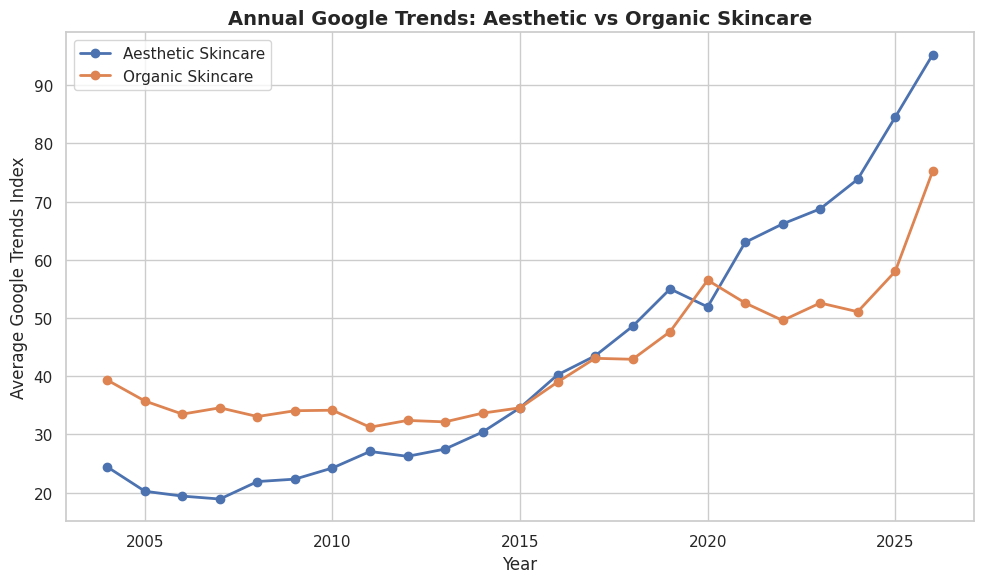

In [30]:
# ============================================================
# Visualise Annual Google Trends
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    annual_trends["Year"],
    annual_trends["Aesthetic_Trend"],
    marker="o",
    linewidth=2,
    label="Aesthetic Skincare"
)

plt.plot(
    annual_trends["Year"],
    annual_trends["Organic_Trend"],
    marker="o",
    linewidth=2,
    label="Organic Skincare"
)

plt.title(
    "Annual Google Trends: Aesthetic vs Organic Skincare",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Average Google Trends Index")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

### Interpretation

The temporal analysis illustrates how global interest in aesthetic and organic skincare evolved throughout the available observation period.

Comparing both trend lines provides an overview of changing consumer interest and establishes the temporal context used throughout the remaining analyses. These annual trend values are subsequently integrated with consumer review data to investigate whether changes in global interest are associated with consumer ratings and behavioural patterns.

In [31]:
import os

os.makedirs("results", exist_ok=True)

plt.savefig(
    "results/temporal_trend_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

## 6.2 Geographical Preference Analysis

Consumer interest in skincare varies across different regions of the world. To understand these geographical differences, the country-level dataset is analysed by comparing the relative popularity of organic skincare and aesthetic skincare.

The difference between these two measures is represented as the **Trend Gap**, allowing countries with stronger aesthetic or organic preferences to be identified.

In [34]:
# ============================================================
# 6.2 Geographical Preference Analysis
# ============================================================

# Calculate the difference between aesthetic and organic preferences
country_df["Trend_Gap"] = (
    country_df["Aesthetic"] -
    country_df["Organic"]
)

# Display summary statistics
display(country_df.describe())

,Organic,Aesthetic,Trend_Gap
count,60.000000,55.000000,55.000000
mean,72.266667,30.254545,-39.490909
std,13.737079,11.335324,22.670647
min,27.000000,1.000000,-98.000000
25%,64.750000,23.000000,-54.000000
50%,70.000000,31.000000,-38.000000
75%,79.000000,36.500000,-27.000000
max,100.000000,73.000000,46.000000


In [35]:
# ============================================================
# Countries with Highest Aesthetic Preference
# ============================================================

top_aesthetic = (
    country_df
    .sort_values("Trend_Gap", ascending=False)
    .head(10)
)

display(top_aesthetic)

,Country,Organic,Aesthetic,Trend_Gap
59,Indonesia,27.0,73.0,46.0
51,Finland,51.0,49.0,-2.0
38,Greece,53.0,47.0,-6.0
66,Argentina,55.0,45.0,-10.0
65,Türkiye,56.0,44.0,-12.0
61,Egypt,57.0,43.0,-14.0
7,Singapore,59.0,41.0,-18.0
64,Mexico,59.0,41.0,-18.0
35,Switzerland,61.0,39.0,-22.0
43,Austria,61.0,39.0,-22.0


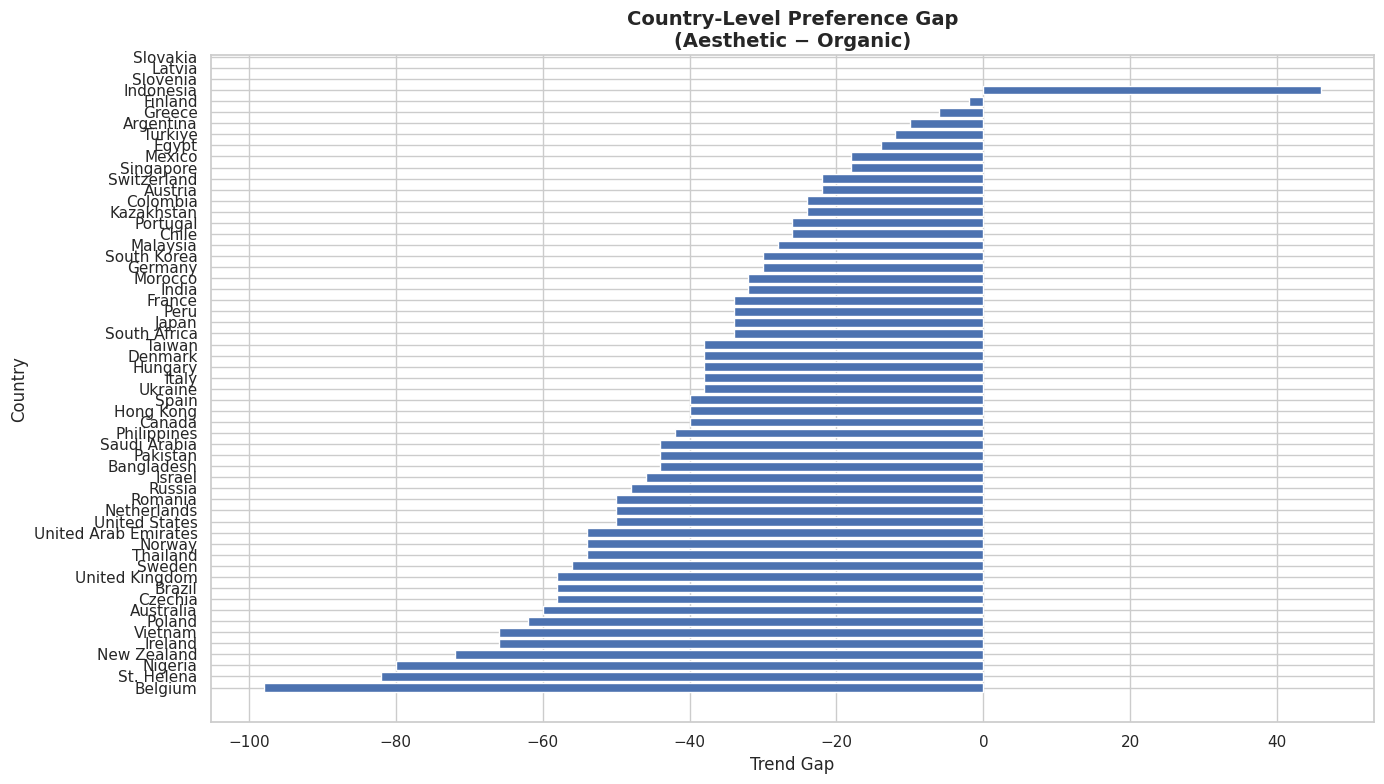

In [36]:
# ============================================================
# Country Preference Gap
# ============================================================

plt.figure(figsize=(14,8))

country_sorted = country_df.sort_values("Trend_Gap")

plt.barh(
    country_sorted["Country"],
    country_sorted["Trend_Gap"]
)

plt.title(
    "Country-Level Preference Gap\n(Aesthetic − Organic)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Trend Gap")
plt.ylabel("Country")

plt.tight_layout()

import os
os.makedirs("results", exist_ok=True)

plt.savefig(
    "results/country_preference_gap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The geographical analysis highlights substantial variation in skincare preferences across countries. While most countries demonstrate stronger interest in organic skincare, a smaller number show relatively higher interest in aesthetic skincare.

These findings indicate that consumer preferences are influenced by regional differences and that global skincare trends are not uniformly reflected across international markets.

## 6.3 Country-Level Distribution Analysis

To further examine geographical variation, a scatter plot is used to compare organic and aesthetic skincare preferences across countries. This visualization highlights overall distribution patterns, balanced markets, and potential outliers.

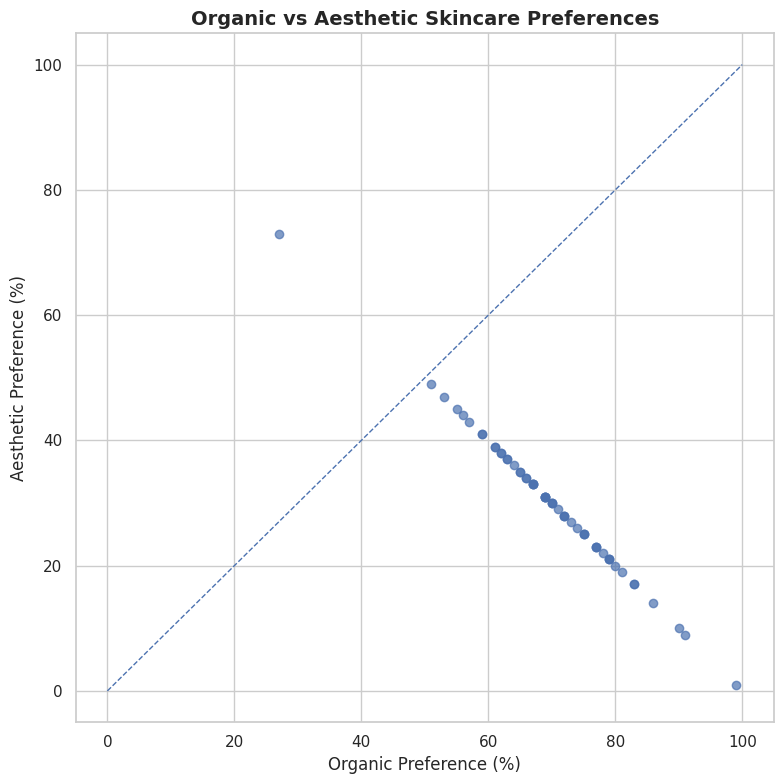

In [37]:
# ============================================================
# Country-Level Distribution
# ============================================================

plt.figure(figsize=(8,8))

plt.scatter(
    country_df["Organic"],
    country_df["Aesthetic"],
    alpha=0.7
)

# Reference line
plt.plot(
    [0,100],
    [0,100],
    linestyle="--",
    linewidth=1
)

plt.title(
    "Organic vs Aesthetic Skincare Preferences",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Organic Preference (%)")
plt.ylabel("Aesthetic Preference (%)")

plt.tight_layout()

plt.savefig(
    "results/country_distribution_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The scatter plot provides a comprehensive overview of country-level skincare preferences. Countries positioned below the reference line exhibit stronger organic skincare interest, whereas those above the line demonstrate relatively higher aesthetic preference.

The distribution also highlights the presence of regional variability, reinforcing that consumer behaviour differs considerably across geographical markets.

### Interpretation

The scatter plot provides a comprehensive overview of country-level skincare preferences. Countries positioned below the reference line exhibit stronger organic skincare interest, whereas those above the line demonstrate relatively higher aesthetic preference.

The distribution also highlights the presence of regional variability, reinforcing that consumer behaviour differs considerably across geographical markets.

In [38]:
# ============================================================
# Correlation Analysis
# ============================================================

correlation_features = product_analysis[
    [
        "Average_Rating",
        "Aesthetic_Trend",
        "Organic_Trend",
        "Trend_Gap"
    ]
]

correlation_matrix = correlation_features.corr()

display(correlation_matrix)

,Average_Rating,Aesthetic_Trend,Organic_Trend,Trend_Gap
Average_Rating,1.000000,0.109731,0.043936,0.097264
Aesthetic_Trend,0.109731,1.000000,0.148707,0.958740
Organic_Trend,0.043936,0.148707,1.000000,-0.138554
Trend_Gap,0.097264,0.958740,-0.138554,1.000000


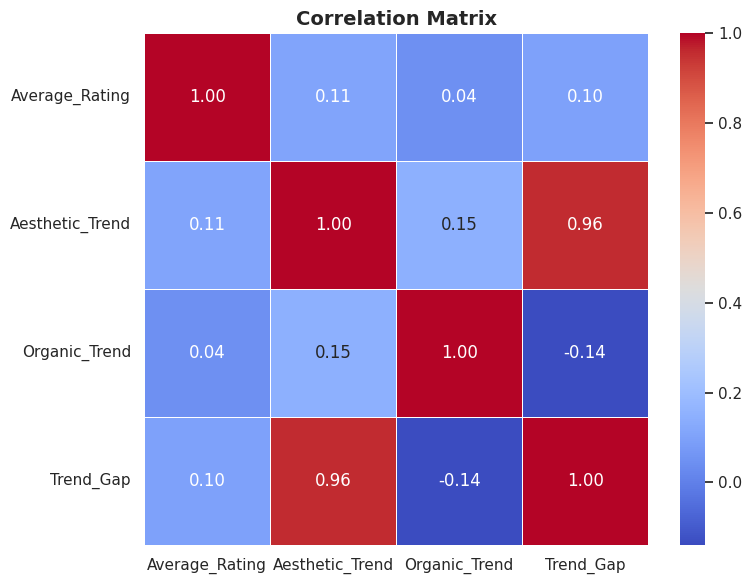

In [39]:
# ============================================================
# Correlation Heatmap
# ============================================================

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title(
    "Correlation Matrix",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "results/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:
# ============================================================
# Pearson Correlation
# ============================================================

correlation, p_value = pearsonr(
    product_analysis["Average_Rating"],
    product_analysis["Trend_Gap"]
)

print("=" * 70)
print("Pearson Correlation Analysis")
print("=" * 70)

print(f"Correlation Coefficient : {correlation:.4f}")
print(f"P-value                 : {p_value:.4f}")

Pearson Correlation Analysis
Correlation Coefficient : 0.0973
P-value                 : 0.0000


In [41]:
# ============================================================
# Linear Regression
# ============================================================

X = product_analysis[
    [
        "Aesthetic_Trend",
        "Organic_Trend"
    ]
]

y = product_analysis["Average_Rating"]

model = LinearRegression()

model.fit(X, y)

r2 = model.score(X, y)

print("=" * 70)
print("Linear Regression Performance")
print("=" * 70)

print(f"R² Score : {r2:.4f}")

Linear Regression Performance
R² Score : 0.0128


### Interpretation

The correlation analysis indicates that global skincare trends exhibit only a weak relationship with consumer ratings. Similarly, the linear regression model demonstrates limited explanatory power, suggesting that trend variables alone are insufficient to predict consumer satisfaction.

These findings indicate that consumer behaviour is influenced by additional latent factors beyond global trend dynamics.

Consequently, rather than pursuing a predictive modelling approach, the analysis proceeds with **unsupervised machine learning** to identify hidden behavioural segments within the data.

## 6.5 Machine Learning-Based Behavioural Segmentation

Following the correlation analysis, an unsupervised machine learning approach is applied to identify hidden behavioural patterns within the product data.

Since the relationship between global trends and consumer ratings was found to be weak, K-Means clustering is used as an exploratory technique to group products with similar behavioural characteristics.

The clustering model is built using:

- Average Product Rating
- Trend Gap (Aesthetic − Organic)

These features allow products with similar consumer responses and trend exposure to be grouped without requiring labelled data.

In [42]:
# ============================================================
# Select Features for Clustering
# ============================================================

clustering_data = product_analysis[
    [
        "Average_Rating",
        "Trend_Gap"
    ]
].copy()

display(clustering_data.head())

,Average_Rating,Trend_Gap
0,4.000000,-5.839286
1,2.750000,-11.572917
2,3.642857,-10.607143
3,3.445255,-4.936740
4,4.634409,-5.965352


In [43]:
# ============================================================
# Feature Scaling
# ============================================================

scaler = StandardScaler()

scaled_features = scaler.fit_transform(clustering_data)

print("Feature scaling completed.")

Feature scaling completed.


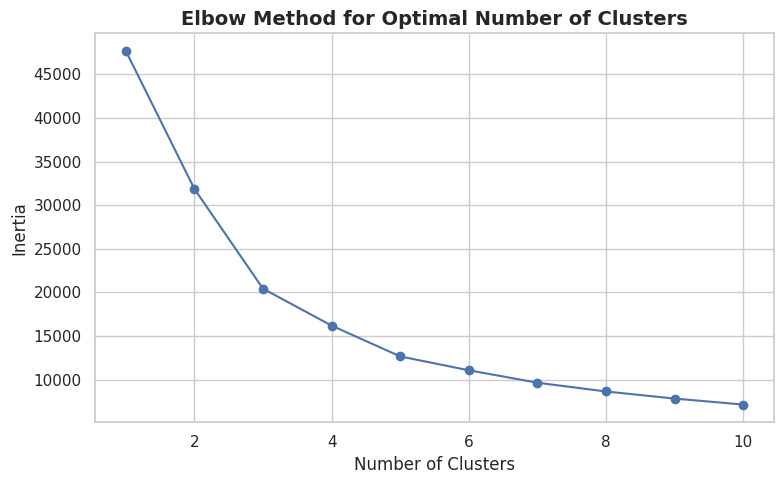

In [44]:
# ============================================================
# Determine Optimal Number of Clusters
# ============================================================

inertia = []

cluster_range = range(1, 11)

for k in cluster_range:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    cluster_range,
    inertia,
    marker="o"
)

plt.title(
    "Elbow Method for Optimal Number of Clusters",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "results/elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
# ============================================================
# K-Means Clustering
# ============================================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

product_analysis["Cluster"] = kmeans.fit_predict(
    scaled_features
)

print("K-Means model trained successfully.")

K-Means model trained successfully.


In [46]:
# ============================================================
# Cluster Summary
# ============================================================

cluster_summary = (
    product_analysis
    .groupby("Cluster")
    .agg({
        "Average_Rating": "mean",
        "Trend_Gap": "mean"
    })
    .round(2)
)

cluster_summary["Count"] = (
    product_analysis["Cluster"]
    .value_counts()
    .sort_index()
)

display(cluster_summary)

,Average_Rating,Trend_Gap,Count
Cluster,,,
0,4.05,-8.29,1812
1,4.40,-4.70,15929
2,3.53,-4.75,6097


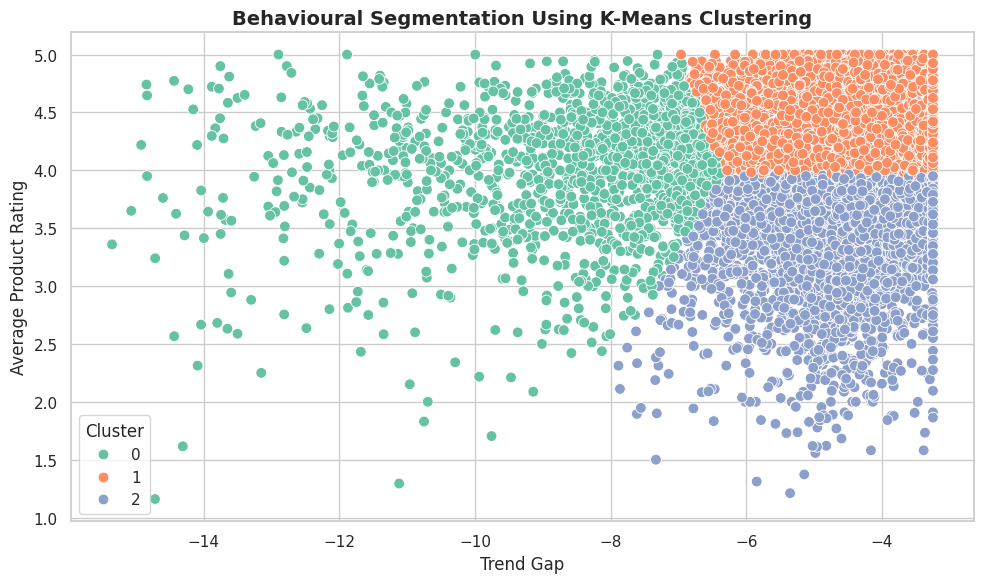

In [47]:
# ============================================================
# Cluster Visualization
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=product_analysis,
    x="Trend_Gap",
    y="Average_Rating",
    hue="Cluster",
    palette="Set2",
    s=60
)

plt.title(
    "Behavioural Segmentation Using K-Means Clustering",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Trend Gap")

plt.ylabel("Average Product Rating")

plt.tight_layout()

plt.savefig(
    "results/kmeans_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The K-Means model identified three distinct behavioural segments based on consumer ratings and trend exposure.

The results indicate that products experiencing similar global trend conditions can exhibit different levels of consumer satisfaction, suggesting that trend popularity alone does not explain purchasing behaviour or product perception.

These behavioural segments provide additional insight beyond traditional statistical analysis and demonstrate the value of unsupervised machine learning for consumer analytics.

# 7. Key Findings and Conclusion

The integrated analysis demonstrates that combining consumer review data with external trend information provides a more comprehensive understanding of skincare behaviour than analysing either source independently.

By integrating temporal trends, geographical preferences, statistical analysis, and machine learning, the study identifies meaningful behavioural patterns that are not apparent through conventional descriptive analysis alone.

In [48]:
# ============================================================
# Project Summary
# ============================================================

print("=" * 70)
print("PROJECT SUMMARY")
print("=" * 70)

print("""
Key Findings

1. Consumer ratings show only a weak relationship with global skincare trends.

2. Organic skincare remains more popular than aesthetic skincare across
   the majority of countries analysed.

3. Consumer preferences vary considerably across geographical regions,
   highlighting the importance of regional market analysis.

4. K-Means clustering successfully identified distinct behavioural
   segments based on consumer ratings and trend exposure.

5. Products exposed to similar trend conditions can receive different
   consumer ratings, suggesting that additional factors influence
   customer satisfaction beyond global trends alone.

Overall Conclusion

This project demonstrates how integrating multiple data sources with
machine learning can provide deeper insights into consumer behaviour
than analysing individual datasets independently.
""")

PROJECT SUMMARY

Key Findings

1. Consumer ratings show only a weak relationship with global skincare trends.

2. Organic skincare remains more popular than aesthetic skincare across
   the majority of countries analysed.

3. Consumer preferences vary considerably across geographical regions,
   highlighting the importance of regional market analysis.

4. K-Means clustering successfully identified distinct behavioural
   segments based on consumer ratings and trend exposure.

5. Products exposed to similar trend conditions can receive different
   consumer ratings, suggesting that additional factors influence
   customer satisfaction beyond global trends alone.

Overall Conclusion

This project demonstrates how integrating multiple data sources with
machine learning can provide deeper insights into consumer behaviour
than analysing individual datasets independently.



## Final Remarks

This project demonstrates a complete end-to-end consumer analytics workflow, including data preparation, data integration, exploratory analysis, feature engineering, statistical evaluation, and unsupervised machine learning.

The methodology presented in this notebook can be extended to other consumer-focused domains where behavioural patterns are influenced by both external market trends and customer feedback.

Future improvements may include incorporating additional product attributes, demographic information, and advanced machine learning techniques to further enhance behavioural segmentation and predictive analytics.